# Hierarchial Audio Classification Using Deep Learning

## Section 0: Imports & Configurations

### Configurations

In [1]:
DATASET = "urbansound8k" # Choose any available dataset from the 'soundata' library
SPECTROGRAM_METHOD = "Mel" # Choose a spectrogram representation: 'STFT', 'Mel', 'MFCCs'

### Import modules

In [2]:
import soundata
import librosa
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
import ast

### Download Dataset
NOTE: If you already have "DATASET" downloaded and verified, you can skip running this section

In [14]:
dataset = soundata.initialize(DATASET)
try:
    dataset.validate()
except:
    dataset.download()  # download the dataset
    dataset.validate()  # validate that all the expected files are there

INFO: Downloading ['all', 'index']. Index is being stored in /Users/aleks/.pyenv/versions/3.12.12/lib/python3.12/site-packages/soundata/datasets/indexes, and the rest of files in /Users/aleks/sound_datasets/urbansound8k
INFO: [all] downloading UrbanSound8K.tar.gz
5.61GB [16:02, 6.26MB/s]                               
INFO: [index] downloading urbansound8k_index_1.0.json
1.15MB [00:00, 2.00MB/s]                            
100%|██████████| 8732/8732 [00:14<00:00, 584.35it/s]
INFO: Success: the dataset is complete and all files are valid.
INFO: --------------------


## Section 1: Preprocessing of data

### Tagging of Data and Defining class hierarchy

#### Urbansound
Urbansound does not include a hierachical structure, hence we define our own.

In [5]:
urbansound_id_dict = {0 : "air_conditioner",1 : "car_horn",2 : "children_playing",3 : "dog_bark",4 : "drilling",5 :"engine_idling",6 : "gun_shot",7 : "jackhammer",8 : "siren",9 : "street_music"}

# Define Hierachy structure
hierarchy_US = {
    "human_animal" : [
        {"human": ["children_playing", "street_music"]},
        {"animal": ["dog_bark"]} ],

    "vehicle" : [
        {"vehicle_operation": ["engine_idling"]},
        {"vehicle_signal": ["car_horn", "siren"]}],

    "mechanical": [
        {"construction_tools": ["drilling", "jackhammer"]},
        {"machinery": ["air_conditioner"]}],

    "impact": [
        {"hazardous": ["gun_shot"]}]
    }





#### Hierarchy label functions

All data will have the hierachical label structure defined as a list: ```hierarchy = [level_1, level_2, ..., level_n]```
- Where the lowest index labels the most coarse level, and the highest index labels the finest level.

In [4]:
def build_label_paths(hierarchy):
    """
    Build mapping: fine_label -> full hierarchy path

    returns: 
        a dictionary with the finest label as the key,
        that points to a list with each index corresponding to the hierarchy label on depth "i"
    """

    label_to_path = {}

    def traverse(node, path):
        if isinstance(node, dict):
            for key, value in node.items():
                traverse(value, path + [key])

        elif isinstance(node, list):
            for item in node:
                traverse(item, path)

        elif isinstance(node, str):
            # leaf node (actual class)
            label_to_path[node] = path + [node]

    traverse(hierarchy, [])
    return label_to_path


def get_max_depth(label_paths):
    return max(len(p) for p in label_paths.values())


def encode_hierarchy(label, label_paths, max_depth):
    """
    Convert label into padded hierarchy levels
    (Automatically pads paths, if the hiearchy does not have equal length along the whole path)
    """
    path = label_paths.get(label, [None])

    # pad to max depth
    padded = path + [None] * (max_depth - len(path))
    return padded

In [5]:
# Choose a hierachy structure
hierarchy = hierarchy_US 

label_paths = build_label_paths(hierarchy) # Returns unpadded label paths -> for fine levels only
max_depth = get_max_depth(label_paths) # Retrieve max depth of the hierarchy (Used for padding)

# Output hierarchy index path for a fine level.
hierarchy_structure = encode_hierarchy(label="dog_bark", label_paths=label_paths, max_depth=max_depth)
print(hierarchy_structure)

['human_animal', 'animal', 'dog_bark']


#### Write Data to CSV
Meta data, will include: Hierachical Label structure 

In [8]:
# Output folder
out_dir = Path("metadata")
out_dir.mkdir(parents=True, exist_ok=True)

def write_csv(output_path, rows):
    with open(output_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved {len(rows)} clips to: {output_path}")

# Save Datasets to CSV
if DATASET == "urbansound8k":
    output_path = out_dir / "urbansound8k_metadata.csv"
    label_paths = build_label_paths(hierarchy_US)
    max_depth = get_max_depth(label_paths)

    rows = []
    for clip_id in dataset.clip_ids:
        clip = dataset.clip(clip_id)

        rows.append({
            "clip_id": clip.clip_id,
            "class_id": clip.class_id,
            "freesound_start_time": clip.freesound_start_time,
            "freesound_end_time": clip.freesound_end_time,
            "salience": clip.salience,
            "slice_file_name": clip.slice_file_name,
            
            "class_label": clip.class_label,
            "hierarchy": encode_hierarchy(label= clip.class_label, label_paths=label_paths, max_depth=max_depth)
        })
    write_csv(output_path, rows)


Saved 8732 clips to: metadata\urbansound8k_metadata.csv


### Data Visualization and Statistics

#### Utility functions for data visualization

In [6]:
def load_with_parsed_hierarchy(csv_path):
    """ 
    Only returns the "hierarchy" column from the meta dataset
    
    """
    df = pd.read_csv(csv_path)
    
    # Convert string → list
    df["hierarchy"] = df["hierarchy"].apply(ast.literal_eval)
    
    return df

def count_by_hierarchy_level(df, level, normalized=False):
    """
    Count occurrences of labels at a given hierarchy level
    
    Args:
        df: pandas DataFrame
        level: int (e.g. 0, 1, 2)
        
    Returns:
        pandas Series (label -> count)
    """
    
    def get_level(h):
        if isinstance(h, list) and len(h) > level:
            return h[level]
        return None

    counts = df["hierarchy"].apply(get_level).value_counts(dropna=True)
    if normalized:
        total = sum(counts)
        counts = counts / total
    
    return counts

def plot_hierarchy_distribution(counts, level, sort=True):
    """
    Plot histogram of hierarchy counts
    
    Args:
        counts: pandas Series from count_by_hierarchy_level
        level: int (for labeling)
        sort: sort bars descending
    """
    
    if sort:
        counts = counts.sort_values(ascending=False)

    plt.figure()
    counts.plot(kind="bar")
    
    plt.title(f"Hierarchy Level {level} Distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

def stacked_distribution(df, level_parent, level_child):
    """
    Create a pivot table for stacked plotting
    
    Args:
        df: DataFrame with parsed hierarchy
        level_parent: int (e.g. 0)
        level_child: int (e.g. 1)
        
    Returns:
        pivot table (parent x child counts)
    """

    def get_level(h, level):
        if isinstance(h, list) and len(h) > level:
            return h[level]
        return None

    temp = pd.DataFrame({
        "parent": df["hierarchy"].apply(lambda h: get_level(h, level_parent)),
        "child": df["hierarchy"].apply(lambda h: get_level(h, level_child)),
    })

    pivot = pd.crosstab(temp["parent"], temp["child"])

    return pivot

def plot_stacked_distribution(pivot, normalize=False):
    """
    Plot stacked bar chart
    
    Args:
        pivot: DataFrame from stacked_distribution
        normalize: if True, show proportions instead of counts
    """

    if normalize:
        pivot = pivot.div(pivot.sum(axis=1), axis=0)

    pivot.plot(kind="bar", stacked=True)

    plt.title("Stacked Hierarchy Distribution")
    plt.xlabel("Parent Level")
    plt.ylabel("Proportion" if normalize else "Count")
    plt.xticks(rotation=45, ha="right")

    plt.legend(title="Child Level", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()


#### Histograms pr. hierarchy level 

Use the tools to assess the class imbalance

The section below allows for 2D plots:

hierarchy
human_animal    3000
mechanical      3000
vehicle         2358
impact           374
Name: count, dtype: int64


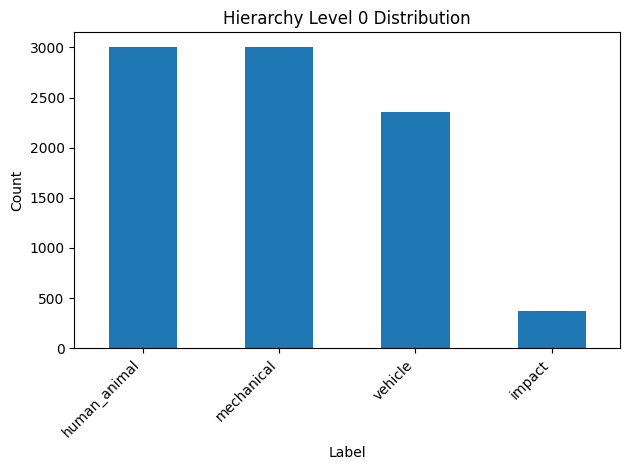

hierarchy
human                 2000
construction_tools    2000
vehicle_signal        1358
machinery             1000
vehicle_operation     1000
animal                1000
hazardous              374
Name: count, dtype: int64


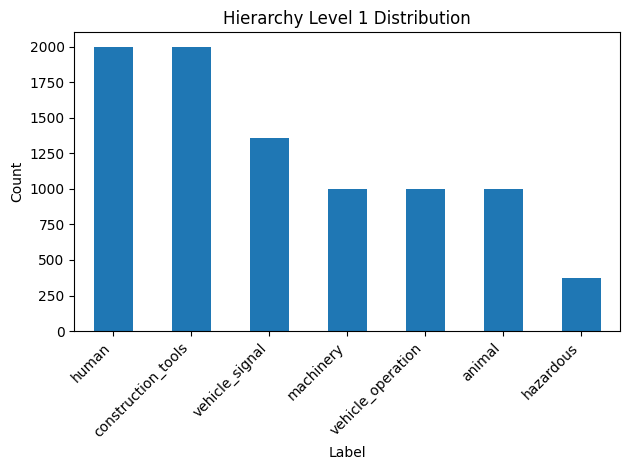

hierarchy
children_playing    1000
air_conditioner     1000
jackhammer          1000
drilling            1000
engine_idling       1000
dog_bark            1000
street_music        1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64


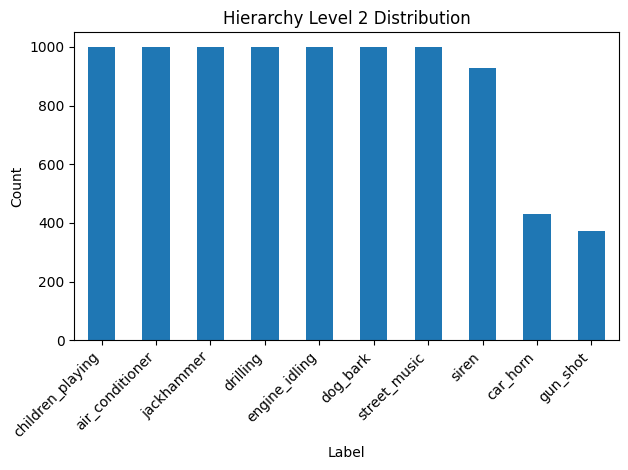

In [7]:
# For URBANSOUND8k
df = load_with_parsed_hierarchy("metadata/urbansound8k_metadata.csv")

# Level 0 (coarse categories)
counts_lvl0 = count_by_hierarchy_level(df, level=0, normalized=False)
print(counts_lvl0)
plot_hierarchy_distribution(counts_lvl0, level=0)

# Level 1 (mid labels)
counts_lvl1 = count_by_hierarchy_level(df, level=1, normalized=False)
print(counts_lvl1)
plot_hierarchy_distribution(counts_lvl1, level=1)

# Level 2 (fine labels)
counts_lvl2 = count_by_hierarchy_level(df, level=2, normalized=False)
print(counts_lvl2)
plot_hierarchy_distribution(counts_lvl2, level=2)

This section below allows for stacked distribution tables:

child         air_conditioner  car_horn  children_playing  dog_bark  drilling  \
parent                                                                          
human_animal                0         0              1000      1000         0   
impact                      0         0                 0         0         0   
mechanical               1000         0                 0         0      1000   
vehicle                     0       429                 0         0         0   

child         engine_idling  gun_shot  jackhammer  siren  street_music  
parent                                                                  
human_animal              0         0           0      0          1000  
impact                    0       374           0      0             0  
mechanical                0         0        1000      0             0  
vehicle                1000         0           0    929             0  


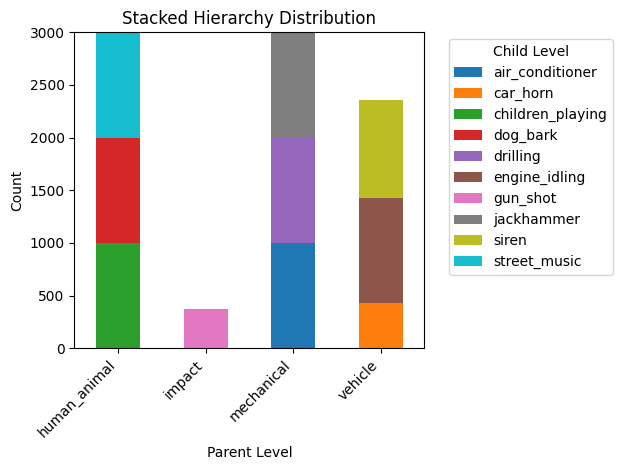

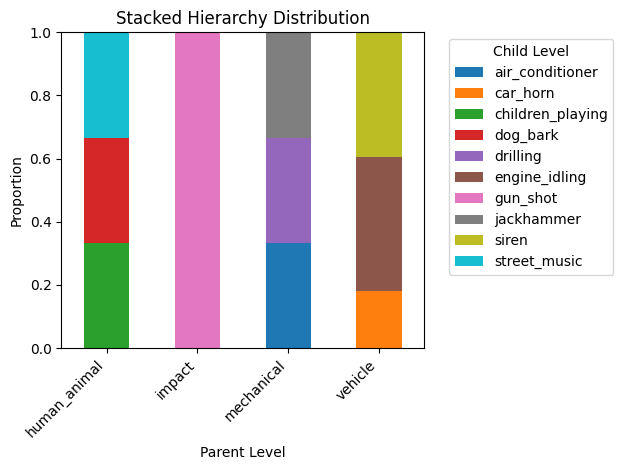

In [8]:
df = load_with_parsed_hierarchy("metadata/urbansound8k_metadata.csv")

# Level 0 → Level 1
pivot = stacked_distribution(df, level_parent=0, level_child=2)

print(pivot)

plot_stacked_distribution(pivot, normalize=False)   # raw counts
plot_stacked_distribution(pivot, normalize=True)    # proportions

Alternatively, you could also make a "Sunburst" plot..

### Signal Processing

#### Theoretic notes (Draft)

In [ ]:
"""
Waveform:
|------n_fft------|
[Frame 1]
        |------n_fft------|
        [Frame 2]
                |------n_fft------|
                [Frame 3]

- The width of each window = n_fft

- The step between windows = hop_length

- Due to the Newquist Rate = (f_s / 2), the frequency range of the spectrogram will always be
  constrained to the length of the sample width [0Hz, f_s / 2]. 
  The Nyquist rate sets the maximum frequency you can represent.

"""

#### Utility functions for Audio processing

In [9]:
def extract_features(y, sr, mode="Mel", n_fft=2048, hop_length=512, n_mels=128, n_mfcc=20):
    """
    y       :  audio time-series, np.ndarray [shape=(..., n)]
    sr      :  sampling rate, number > 0 [scalar]
    mode    :  spectrogram representation, [string]

    returns :
      np.ndarray
      - "STFT": dB magnitude spectrogram shape (n_fft/2+1, t)
      - "Mel": dB mel spectrogram shape (128, t)
      - "MFCCs": MFCC matrix shape (20, t)

    NOTE: 
        n_mels or n_mfcc: controls number of mel bands (i.e., frequency bins after mel filterbank).
    """

    if mode == "STFT":
        S = np.abs(librosa.stft(y))
        return librosa.amplitude_to_db(S, n_fft=n_fft, hop_length=hop_length, ref=np.max)

    elif mode == "Mel":
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
        return librosa.power_to_db(S, ref=np.max)

    elif mode == "MFCCs":
        return librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mfcc=n_mfcc)


def plot_spectrogram(S_db, sr, hop_length=512, mode="Mel", cmap="viridis"):
    """
    S_db   : np.ndarray feature matrix in dB (output of extract_features)
    sr     : sample rate
    hop_length: hop length used for STFT/mel (same as used for compute)
    mode   : "STFT" | "Mel" | "MFCCs"
    """
    if mode == "Mel":
        y_axis = "mel"
    elif mode == "STFT":
        y_axis = "linear"
    elif mode == "MFCCs":
        y_axis = "mel"   # any order axis works; MFCC is not freq axis but frame x coef
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    plt.figure(figsize=(8, 4))
    librosa.display.specshow(S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis,
        fmin=0,
        fmax= sr / 2, # Nyquist sampling theorem
        cmap=cmap,
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{mode} spectrogram (dB)")
    plt.tight_layout()
    plt.show()

#### (Example) Plotting the spectrogram of Sound Data

In [23]:
example_clip = dataset.choice_clip()  # choose a random example clip
print(example_clip)  # see the available data

Clip(
  audio_path="/Users/aleks/sound_datasets/urbansound8k/audio/fold2/96475-9-0-6.wav",
  clip_id="96475-9-0-6",
  audio: The clip's audio
            * np.ndarray - audio signal
            * float - sample rate,
  class_id: The clip's class id.
            * int - integer representation of the class label (0-9). See Dataset Info in the documentation for mapping,
  class_label: The clip's class label.
            * str - string class name: air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, siren, street_music,
  fold: The clip's fold.
            * int - fold number (1-10) to which this clip is allocated. Use these folds for cross validation,
  freesound_end_time: The clip's end time in Freesound.
            * float - end time in seconds of the clip in the original freesound recording,
  freesound_id: The clip's Freesound ID.
            * str - ID of the freesound.org recording from which this clip was taken,
  freesound_start_ti

/Users/aleks/.pyenv/versions/3.12.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


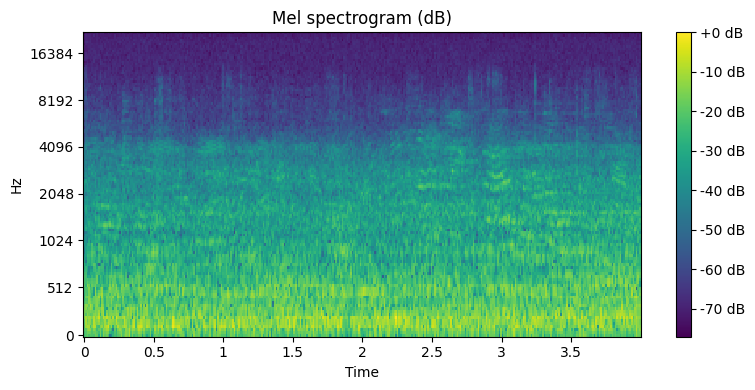

In [16]:
n_fft = 1024
hop_len = 512

# Plot Spectrogram
S_F = extract_features(*example_clip.audio, mode=SPECTROGRAM_METHOD, n_fft=n_fft, hop_length=hop_len)
plot_spectrogram(S_F, example_clip.audio[1], hop_length=hop_len, mode=SPECTROGRAM_METHOD, cmap="viridis")

#### Data Augmentation

In [ ]:
# TODO

## Section 2: Model

#### Dataset Adapter

Many datasets are gathered in many different formats, therefore most pipelines can't support to directly process multiple different datasets, straight into it's dataloader. Important data such as, class labels and raw data can be structured differently, depending on how it's imported

Therefore we need a Dataset Adapter layer above the PyTorch dataloader that handles:
- metadata parsing (CSV, hierarchy, labels)
- dataset quirks (UrbanSound vs ESC50 vs custom)
- other dataset specific logic
And finally outputs a clean standardized object, that can be passed straight into the AudioDataset loader.

<span style="color:lightblue; font-weight:bold;">NOTE: </span>It's very important to note that the Dataset Adapter must be outside the model pipeline, as an offline dataset compilation. To reduce complexity, recomputing the dataset format to match the AudioDataset loader everytime the pipeline runs, should be avoided. Therefore, the Data Adapter will work as a light data processing layer on the designated dataset, right before the model pipeline loop.

In [25]:
# We will save a designated dataframe (CSV) coressponding to a distinct dataset in data/.
#  
# Therefore it will only be necessary to run the Data Adapter once pr. dataset and the constructed dataframe
# can just be directly passed straight into the AudioDataset henceforth.

out_dir = Path("data")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------- Conduct branched flow based on dataset -----------------

if DATASET == "urbansound8k":
    # Load your existing metadata CSV
    meta_path = Path("metadata/urbansound8k_metadata.csv")
    df_meta = pd.read_csv(meta_path)

    rows = []

    for _, row in df_meta.iterrows():

        clip_id = row["clip_id"]

        # Get clip from soundata
        clip = dataset.clip(clip_id)

        # Build audio path
        audio_path = clip.audio_path  # already correct path

        # Parse hierarchy (stored as string in CSV)
        hierarchy = row["hierarchy"]
        if isinstance(hierarchy, str):
            hierarchy = ast.literal_eval(hierarchy)

        rows.append({
            "clip_id": clip_id,
            "audio_path": str(audio_path),
            "class_id": int(row["class_id"]),
            "class_label": row["class_label"],
            "fold": int(clip.fold),
            "hierarchy": hierarchy
        })

    df_out = pd.DataFrame(rows)

    # Save compiled dataset
    output_path = out_dir / "urbansound8k_compiled.csv"
    df_out.to_csv(output_path, index=False)

    print(f"Saved {len(df_out)} samples to: {output_path}")

    



Saved 8732 samples to: data/urbansound8k_compiled.csv


In [30]:
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import soundfile as sf


#### Convolutional Block

A generalized convolutional block class, you can build and apply in various CNN arcitectures.

In [ ]:
def init_layer(layer):
    
    """
    Initialize the weights and bias of a Linear or Convolutional layer.

    This function applies Xavier (Glorot) uniform initialization to the
    layer's weight tensor and sets the bias to zero if a bias term exists.
    Xavier initialization helps maintain stable gradient magnitudes
    during training, especially for deep networks.

    Parameters
    ----------
    layer : torch.nn.Module
        A PyTorch layer with a `weight` attribute, such as `nn.Linear`,
        `nn.Conv1d`, `nn.Conv2d`, or `nn.Conv3d`. If the layer has a bias,
        it will be initialized to zero.
    """
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, 'bias'):
        if layer.bias is not None:
            layer.bias.data.fill_(0.)

def init_bn(bn):
    """
    Initialize a Batch Normalization layer.

    This function sets the BatchNorm scale parameter (weight, γ) to 1
    and the shift parameter (bias, β) to 0. This ensures that the
    BatchNorm layer initially performs an identity transformation.

    Parameters
    ----------
    bn : torch.nn.modules.batchnorm._BatchNorm
        A PyTorch BatchNorm layer (e.g., `nn.BatchNorm1d`,
        `nn.BatchNorm2d`, or `nn.BatchNorm3d`).
    """
    bn.bias.data.fill_(0.)
    bn.weight.data.fill_(1.)


class ConvBlock(nn.Module):
    def __init__(
        self, 
        in_channels:int, 
        out_channels:int, 
        num_convs:int=2, 
        kernel_size:int=3, 
        stride:int=1, 
        padding=None, 
        activation:str='relu', 
        norm:bool=True, # If true, applies nn.BatchNorm2d between convolutions
        dropout=None, # If true, applies nn.Dropout2d between convolutions
        pool=True,
        pool_size:tuple=(2,2),
        pool_type:str='avg',
        bias=False,
        init_weights=False, # If true, initializes weights with Xavier on every conv in the block
    ):
        super().__init__()

        if padding is None:
            padding = kernel_size // 2
        
        # Build Block, with num_convolutions
        self.layers = []
        for layer in range(num_convs):

            # Define channel structure outside 
            # (Allows for iteratable recudtion inside of the block, in the future)
            in_ch = in_channels if layer == 0 else out_channels
            out_ch = out_channels

            self.layers.append(
                nn.Conv2d(
                    in_ch,
                    out_ch,
                    kernel_size=kernel_size,
                    stride=stride if layer == 0 else 1,
                    padding=padding,
                    bias=bias,
                )
            )
            if norm:
                self.layers.append(nn.BatchNorm2d(out_channels))
            # Apply activation after CONV (+ BN)
            self.layers.append(self._get_activation(activation))
            if dropout is not None:
                # (Apply dropout after CONV (+ BN) + DO)
                self.layers.append(nn.Dropout2d(dropout))

        # Sequence layered convolutions into the block
        self.conv = nn.Sequential(*self.layers)

        # Apply Pooling
        self.pool_type = pool_type
        self.pool_size = pool_size
        if pool:
            if pool_type == 'max':
                self.pool = nn.MaxPool2d(self.pool_size)
            elif pool_type == "avg":
                self.pool = nn.AvgPool2d(self.pool_size)
            elif pool_type == "avg+max": 
                # Will be applied in: forward()
                self.pool = None
            else:
                raise ValueError(f"Unsupported pool_type: {pool_type}")
        else:
            self.pool = None
        
        # Init starting weights
        if init_weights:
            self.init_weight()
    
    def init_weight(self):
        def init_fn(module):
            if isinstance(module, nn.Conv2d):
                init_layer(module)
            elif isinstance(module, nn.BatchNorm2d):
                init_bn(module)

        self.apply(init_fn)
    
    def forward(self, x):

        # Apply the input into the sequential block
        x = self.conv(x) 

        if self.pool_type == "avg+max":
            # Apply flexible pooling
            x = nn.functional.avg_pool2d(x, self.pool_size) + nn.functional.max_pool2d(x, self.pool_size)
        elif self.pool is not None:
            # Apply single pooling set in __init__
            x = self.pool(x) 
        return x

    def _get_activation(self, activation):
        if activation == "relu":
            return nn.ReLU(inplace=True)
        if activation == "leaky_relu":
            return nn.LeakyReLU(0.1, inplace=True)
        if activation == "elu":
            return nn.ELU(inplace=True)
        if activation == "gelu":
            return nn.GELU()
        if activation == "identity" or activation is None:
            return nn.Identity()
        raise ValueError(f"Unsupported activation: {activation}")

#### Datawrapper/loader

For audio data, the waveform representations of the audio signals needs to be processed into spectrogram images, in order for the data to be passed as input into the CNN.

In [ ]:
"""
We define a standard contract, that the Deep Learning model must recieve as input data:

{
    "input": Tensor,      # spectrogram (CNN input)
    "target": int,        # class label,                     → add multiple targets for multiclass learning
    "index": int,         # optional debugging
    "meta": dict          # optional future extensions,      → add "meta": {"hierarchy": tensor}
}

"""

class AudioTransform:
    """
    Convert raw audio waveforms into log-Mel spectrograms.

    This callable transform, applies a Mel spectrogram transformation
    using torchaudio and then performs logarithmic compression to
    produce log-Mel features, which are commonly used in audio and
    speech-related deep learning tasks.

    Parameters
    ----------
    sample_rate : int, optional
        Sample rate of the input audio waveform. Default is 22050 Hz.
    n_mels : int, optional
        Number of Mel frequency bins to use. Default is 64.
    """

    def __init__(self, sample_rate=22050, n_mels=64): # Init Class params
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_mels=n_mels
        )

    def __call__(self, waveform):
        x = self.mel(waveform)
        x = torch.log(x + 1e-6)
        return x


class AudioDataset(Dataset): 
    """
    Generic PyTorch Dataset for audio classification tasks.

    This dataset expects a precompiled pandas DataFrame where each row
    represents one audio sample and contains all necessary metadata to
    load and process the audio into a model-ready tensor.

    The dataset performs:
        1. Audio loading from file path
        2. Optional resampling to a fixed sample rate
        3. Conversion to mono
        4. Transformation into a spectrogram (or other feature representation)

    Parameters
    ----------
    df : pandas.DataFrame
        A dataframe containing at least the following required columns:

        REQUIRED COLUMNS:
        - "audio_path" : str
            Path to the audio file (.wav, .mp3, etc.). Can be absolute or relative.
        - "class_id" : int
            Integer class label used as target for training.

        OPTIONAL COLUMNS:
        - "class_label" : str
            Human-readable label (e.g., "dog_bark"). Used for debugging/analysis.
        - "hierarchy" : list or str
            Hierarchical label structure (e.g., ['human', 'speech']).
            Can be pre-encoded or stringified (will be passed through as-is).
        - "fold" : int
            Fold index for cross-validation (e.g., 1–10 in UrbanSound8K).
        - Any additional metadata columns will be ignored by the dataset
          but can be accessed via the "meta" dictionary.

    transform : callable
        A function or callable object that takes a waveform tensor of shape
        (1, num_samples) and returns a transformed tensor (e.g., spectrogram)
        of shape (1, mel_bins, time_steps).

    sample_rate : int, optional (default=22050)
        Target sample rate. Audio will be resampled if it differs from this value.

    Returns
    -------
    dict
        A dictionary with the following keys:

        - "input" : torch.Tensor
            Transformed audio tensor (e.g., spectrogram) of shape (1, mel_bins, time_steps)
        - "target" : torch.Tensor
            Class label as a tensor of dtype torch.long
        - "index" : int
            Index of the sample in the dataset
        - "meta" : dict
            Dictionary containing optional metadata such as:
                - "label_name"
                - "hierarchy"
                - "fold"

    Notes
    -----
    - This dataset assumes that heavy preprocessing (e.g., dataset-specific logic,
      hierarchy construction, path resolution) has already been performed offline
      by a data adapter.
    - The dataset is designed to be model-agnostic and reusable across different
      audio classification tasks.
    """

    # TODO: SANITY CHECK IT
    # TODO: Add padding/truncation for consistent shapes:

    def __init__(self, df, transform, sample_rate=22050):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.sample_rate = sample_rate

        required_cols = {"audio_path", "class_id"}
        missing = required_cols - set(self.df.columns)
        if missing:
            raise ValueError(f"Missing required columns: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Direct path from CSV
        path = row["audio_path"]



        # TODO: DOWNGRADE TO PYTHON 3.11 TO USE TORCHCODEC, OR USE SOUNDFILE FOR NOW

        # waveform, sr = torchaudio.load(path) # using torchcodec (preinstalled)

        # TODO: ----------------------------------------------------------------

        waveform, sr = sf.read(path) # usign soundfile
        waveform = torch.tensor(waveform, dtype=torch.float32)
        # stereo → mono
        if waveform.ndim == 2:
            waveform = waveform.mean(dim=1)
        # add channel dim (important for CNN)
        waveform = waveform.unsqueeze(0)
        # TODO: ----------------------------------------------------------------



        # mono
        waveform = waveform.mean(dim=0, keepdim=True)

        # optional resample
        if sr != self.sample_rate:
            waveform = torchaudio.functional.resample(
                waveform, sr, self.sample_rate
            )

        # transform → spectrogram
        spec = self.transform(waveform)

        return {
            "input": spec,                              # (1, mel, time)
            "target": torch.tensor(row["class_id"], dtype=torch.long),
            "index": idx,
            "meta": {
                "label_name": row.get("class_label", None),
                "hierarchy": row.get("hierarchy", None),
                "fold": row.get("fold", None)
            }
        }

Sanity check the Dataloader and ensure the espected values:

```
(1, mel_bins, time_steps)
tensor(int)
{...}
```

<span style="color:red; font-weight:bold;">
WARNING: </span> Please consider using python 3.11, if you want to use torchcodec, else you need to use soundfile


In [ ]:
df = pd.read_csv("data/urbansound8k_compiled.csv")

# Check file path validation
print(f"File path for audio exists? = {Path(df.iloc[0]["audio_path"]).exists()}")


transform = AudioTransform(sample_rate=22050, n_mels=64) # remember to init the log-Mel spectrogram transformer
dataset = AudioDataset(df, transform)
sample = dataset[0]

print("Input shape:", sample["input"].shape)
print("Target:", sample["target"])
print("Meta:", sample["meta"])

File path for audio exists? = True
Input shape: torch.Size([1, 64, 442])
Target: tensor(2)
Meta: {'label_name': 'children_playing', 'hierarchy': "['human_animal', 'human', 'children_playing']", 'fold': np.int64(1)}


#### Test CNN

In [ ]:
class TestCNN(nn.Module):
    """ Test CNN for running on Urbansound8k dataset """
    def __init__(self, num_classes=10):
        super().__init__()

        self.blocks = nn.ModuleList([
            ConvBlock(1, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        ])

        self.fc1 = nn.Linear(256, 128)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x):
        # Input: (batch, 1, mel, time)

        for block in self.blocks:
            x = block(x)

        # Global pooling
        x1 = torch.amax(x, dim=[2, 3])
        x2 = torch.mean(x, dim=[2, 3])
        x = x1 + x2

        x = F.relu(self.fc1(x))
        x = self.fc_out(x)

        return x
    


#### Training loop 
- currently is minimal

<span style="color:red; font-weight:bold;">
WARNING: UrbanSound8K is fold-based and needs train on folds 1–9 test on fold 10, with specific data id's already assigned to each fold. If you ignore this, results will be misleading.
</span>


In [ ]:
# TODO: REFACTOR EVERYTHING TO MATCH THE NEW AUDIODATA LOADER

from torch.utils.data import DataLoader

dataset = UrbanSoundDataset(
    "metadata/urbansound8k_metadata.csv",
    "UrbanSound8K/audio"
)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = UrbanSoundCNN(num_classes=10)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()

    for x, y in loader:
        optimizer.zero_grad()

        output = model(x)
        loss = criterion(output, y)

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")